 We will:
1. **Part 1**: Build a Sentiment Classifier. We'll prove why a Transformer is smarter than a standard Neural Network (MLP) by comparing how they handle context.
2. **Part 2**: Build a "Math GPT". You'll train a model to solve algebraic addition from scratch, and test it.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, random
from datasets import load_dataset
from transformers import AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Hardware Target:', device)


## PART 1: The MLP Baseline
To understand why we need Transformers, we first build a simple **MLP**. 
An MLP treats a sentence like a "bag of words"—it averages all word vectors together. 
- **The Problem**: In "Not good," the MLP averages "Not" and "good" indiscriminately. It loses the context that "Not" flips the meaning of "good"!


In [ ]:
print("Downloading Dataset...")
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
dataset = load_dataset('rotten_tomatoes')

def preprocess(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=64)

tokenized = dataset.map(preprocess, batched=True)
tokenized.set_format(type='torch', columns=['input_ids', 'label'])
train_loader = torch.utils.data.DataLoader(tokenized['train'], batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(tokenized['test'], batch_size=256)
nlp_vocab_size = tokenizer.vocab_size


In [ ]:
class ClassicalMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(nlp_vocab_size, 128)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 2)
        
    def forward(self, x):
        # We violently crush the temporal sequence via temporal Mean Pooling
        emb = self.embedding(x)
        pool = emb.mean(dim=1)
        return self.fc2(F.relu(self.fc1(pool)))

mlp = ClassicalMLP().to(device)
print(f"ClassicalMLP Parameters: {sum(p.numel() for p in mlp.parameters() if p.requires_grad):,}")
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)

print("\\n[Training MLP Sentiment Baseline...]")
mlp.train()
for epoch in range(8):
    total_loss = 0
    for batch in train_loader:
        x, y = batch['input_ids'].to(device), batch['label'].to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(mlp(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

mlp.eval()
correct = sum((mlp(b['input_ids'].to(device)).argmax(1) == b['label'].to(device)).sum().item() for b in test_loader)
print(f"\\n--> Final MLP Accuracy on Test Set: {(correct/len(tokenized['test']))*100:.2f}%")


## PART 1.2: The Transformer Core
To fix the MLP's "context blindness," we build the **Transformer Block**. Components:
1. **Positional Encoding**: Gives the model a sense of order (since Attention doesn't care about sequence by default).
2. **Multi-Head Attention**: Lets words "look" at other words in the sentence to gather context.
3. **Feed-forward network** (MLP): Acts like a disentangler for features.

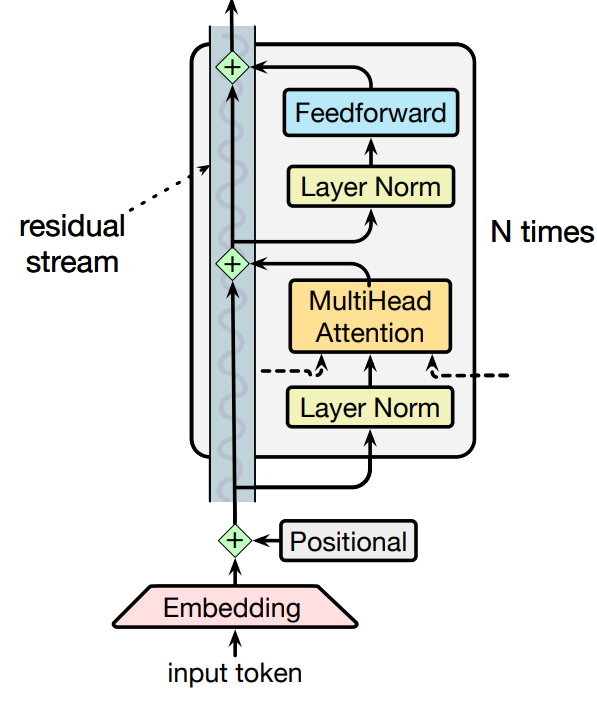

From: https://web.stanford.edu/~jurafsky/slp3/8.pdf

## Positional encodings

Positional encodings are techniques used to inject **order information** into models (especially Transformers), which otherwise process input tokens **in parallel** and have no inherent sense of sequence.

Input to model = Token Embedding + Positional Encoding

| Type        | Learnable | Generalizes | Relative Info | Common Usage        |
|-------------|-----------|-------------|---------------|-------------------|
| Sinusoidal  | ❌        | ✅          | ⚠️ Partial    | Original Transformer |
| Learned     | ✅        | ❌          | ❌            | BERT, early GPT     |
| Relative    | ✅        | ✅          | ✅            | T5, Transformer-XL  |
| RoPE        | ❌        | ✅          | ✅            | LLaMA, GPT-NeoX     |
| ALiBi       | ❌        | ✅          | ✅            | Long-context models |

### Sinusoidal Positional Encoding

For position `pos` and dimension `i`:
PE(pos, 2i) = sin(pos / 10000^(2i / d))
PE(pos, 2i+1) = cos(pos / 10000^(2i / d))

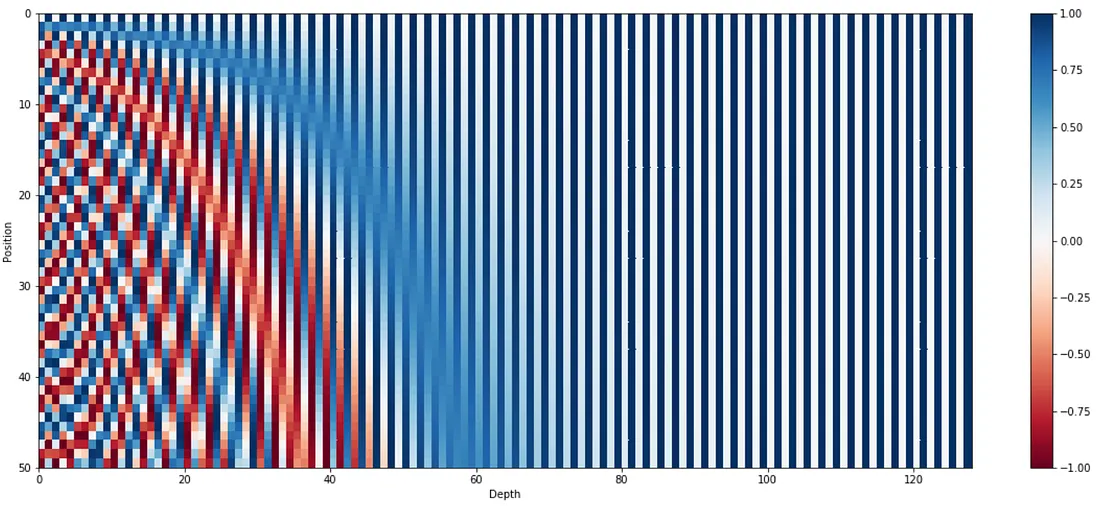

Source: [Mantis NLP – Positional Encodings: Main Approaches](https://medium.com/mantisnlp/positional-encodings-i-main-approaches-bd1199d6770d)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # Create a matrix of shape (max_len, d_model) filled with zeros
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # TODO: Compute the 'div_term' for the sinusoids
        # Formula: exp(arange(0, d_model, 2) * -(log(10000.0) / d_model))
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # TODO: Apply the sinusoidal functions to the 'pe' matrix
        # Even indices (0, 2, ...) should use 'sin'
        # Odd indices (1, 3, ...) should use 'cos'
        # pe[:, 0::2] = ...
        # pe[:, 1::2] = ...
        
        self.register_buffer('pe', pe)

    def forward(self, x):
        # TODO: Add the positional encoding 'pe' to the input 'x'
        # Hint: The 'pe' buffer should be sliced to match the sequence length of 'x'
        # Final shape: (Batch, Seq_Len, d_model)
        return x

# Multi-Head Attention

## 1. Attention in Seq2Seq
- The decoder needs information from the encoder.
- Instead of a single vector, it queries all encoder states.

**Key–Value View:**
- **Keys (K):** descriptors of tokens
- **Values (V):** information stored in tokens
- **Query (Q):** what the current step is looking for


Attention retrieves values weighted by similarity between Q and K.

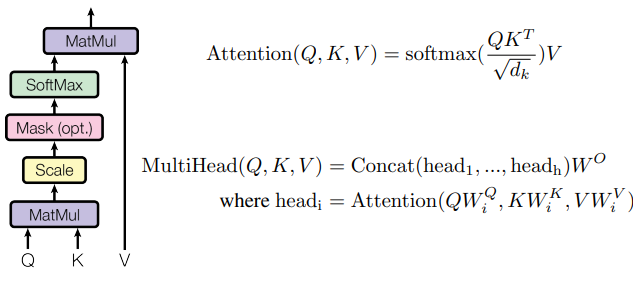

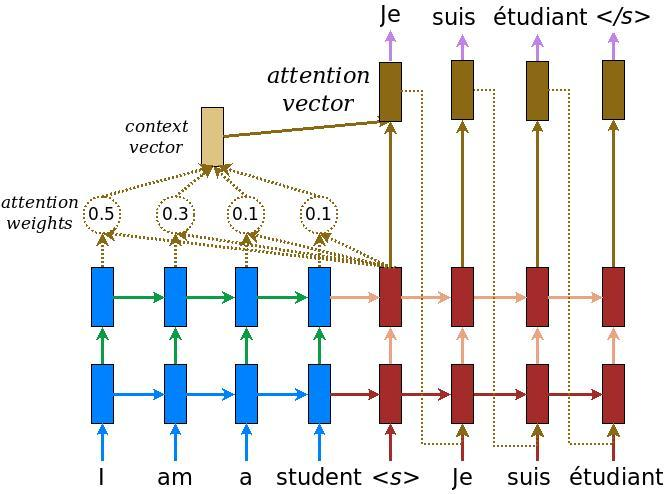

Source: [NMT with Attention](https://www.tensorflow.org/text/tutorials/nmt_with_attention)
 
---

## 2. Self-Attention
- Each token queries all other tokens in the same sequence.
- In regular attention: Q, (K, V) usually from different sentences. In self-attention, from the same.
 

**Interpretation:**
- Tokens act as a shared key–value store.
- Each token forms a query and retrieves relevant information from others.

---

## 3. Multi-Head Attention
- Perform multiple attention operations in parallel.

**Each head:**
- Uses different projections of Q, K, V
- Learns different relationships between tokens


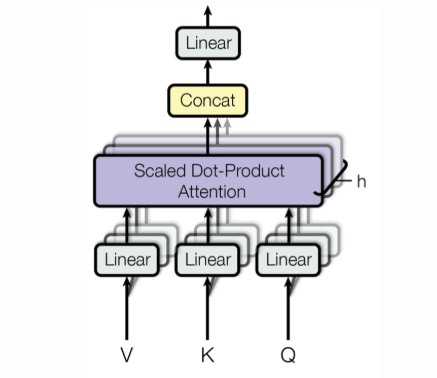



In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.d_k = d_model // heads
        self.heads = heads
        self.w_q = nn.Linear(d_model, d_model); self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model); self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B = x.size(0)
        # 1. Linear projections and reshape to (B, Seq, Heads, d_k) -> transpose to (B, Heads, Seq, d_k)
        q = self.w_q(x).view(B, -1, self.heads, self.d_k).transpose(1, 2)
        k = self.w_k(x).view(B, -1, self.heads, self.d_k).transpose(1, 2)
        v = self.w_v(x).view(B, -1, self.heads, self.d_k).transpose(1, 2)

        # TODO: Compute Scaled Dot-Product Attention
        # Step A: Calculate raw attention scores: (Q @ K^T)
        # Step B: Scale by 1 / sqrt(d_k)
        # Step C: If 'mask' is not None, fill positions where mask == 0 with float('-inf')
        # Step D: Apply Softmax along the last dimension to get weights
        # Step E: Multiply weights by V
        scores = torch.zeros(B, self.heads, x.size(1), x.size(1)).to(x.device)
        
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(B, -1, self.heads * self.d_k)
        return self.w_o(out)


# Layer Normalization in Transformers

**What:** Normalizes each token’s feature vector to mean 0, variance 1, then applies learnable scale/shift.  

**Why:** Stabilizes training, improves gradient flow, works for variable-length sequences.  

**History:** Introduced in 2016 by Ba et al.; became standard in Transformers (BERT, GPT). 

## How LayerNorm Works in a Transformer

1. Take a token’s embedding vector, e.g. `[x₁, x₂, ..., x_d]`, where `d` is the hidden size.  
2. Compute the **mean** and **variance** of this vector

3. Normalize each element
4. Apply a **learnable scale and shift** (`γ` and `β`):

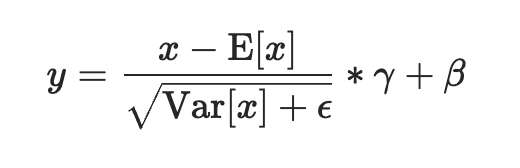

**Key intuition:** Each token vector is “well-behaved” — centered and scaled — before it goes through the next layer.

---

## Why Not BatchNorm?


- **BatchNorm** normalizes across the batch dimension.  
- In Transformers:  
  - Sequence lengths vary  
  - Batch size may be 1 during inference  
  - Each token should be normalized **independently**  

**Conclusion:** LayerNorm is preferred because it normalizes **within each token**, not across the batch.

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, heads, d_ff=256, dropout=0.3):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, heads)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.n1 = nn.LayerNorm(d_model); self.n2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # TODO: Implement the Post-LayerNorm residual architecture
        # 1. Compute self-attention output: self.self_attn(x, mask)
        # 2. Add residual connection: x + dropout(attn_out)
        # 3. Apply first LayerNorm (self.n1)
        # 4. Compute Feed-Forward output: self.ffn(normalized_x)
        # 5. Add second residual connection and second LayerNorm (self.n2)
        return x

### Verification: Core Components
Run the tests below to ensure your Positional Encoding and Attention logic are correct before moving forward!


In [ ]:
# Test Positional Encoding
pe_mod = PositionalEncoding(128)
test_input = torch.zeros(1, 10, 128)
output = pe_mod(test_input)
assert output.shape == (1, 10, 128), f"Expected (1, 10, 128), got {output.shape}"
assert not torch.allclose(output, test_input), "Positional encoding should change the input!"
print("✅ PositionalEncoding: Shape and uniqueness check passed!")

# Test Multi-Head Attention
mha = MultiHeadAttention(128, 8).to(device)
test_x = torch.randn(1, 10, 128).to(device)
out = mha(test_x)
assert out.shape == (1, 10, 128), f"Expected (1, 10, 128), got {out.shape}"
print("✅ MultiHeadAttention: Output shape check passed!")


### Building the Sentiment Transformer
Finally, we wrap everything into a single model.
- **Embedding**: Converts word IDs into vectors.
- **Positional Encoding**: Adds order.
- **Transformer Blocks**: Processes context.
- **Mean Pooling**: Averages all word vectors into one "sentence vector" for classification.


In [ ]:
class SentimentTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(nlp_vocab_size, 128)
        self.pos = PositionalEncoding(128)
        self.blocks = nn.ModuleList([TransformerBlock(128, heads=4) for _ in range(3)])
        self.fc = nn.Linear(128, 2)
        
    def forward(self, x, pad_mask):
        x = self.pos(self.embed(x))
        for block in self.blocks:
            x = block(x, pad_mask)
        
        # TODO: Implement Sentiment Task Pooling
        # In classification, we need a single vector to represent the whole sentence.
        # Compute the 'mean' average across the sequence dimension (dim=1)
        # Expected shape of 'pool': (Batch, 128)
        pool = torch.zeros(x.size(0), 128).to(x.device)
        
        return self.fc(pool)


### Verification: Sentiment Transformer
Check if your Sentiment Transformer handles sequences and outputs the correct class shapes!


In [ ]:
# Test Sentiment Transformer
model_test = SentimentTransformer().to(device)
test_batch = torch.randint(0, nlp_vocab_size, (4, 64)).to(device)
test_mask = torch.ones(4, 1, 1, 64).to(device)
logits = model_test(test_batch, test_mask)
assert logits.shape == (4, 2), f"Expected (4, 2), got {logits.shape}"
print("✅ SentimentTransformer: Shape check passed!")


### Training the Sentiment Transformer
Now let's train our newly built Transformer model on the same dataset as our MLP.
Because it can actively route information using Self-Attention, we should see an improvement over the "bag-of-words" MLP baseline!


In [ ]:
trans_model = SentimentTransformer().to(device)
print(f"SentimentTransformer Parameters: {sum(p.numel() for p in trans_model.parameters() if p.requires_grad):,}")
optimizer = torch.optim.Adam(trans_model.parameters(), lr=0.001)

print("\\n[Training Sentiment Transformer...]")
trans_model.train()
for epoch in range(8):
    total_loss = 0
    for batch in train_loader:
        x, y = batch['input_ids'].to(device), batch['label'].to(device)
        pad_mask = (x != tokenizer.pad_token_id).unsqueeze(1).unsqueeze(2).to(device)
        
        optimizer.zero_grad()
        loss = F.cross_entropy(trans_model(x, pad_mask), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

trans_model.eval()
correct = 0
with torch.no_grad():
    for b in test_loader:
        x, y = b['input_ids'].to(device), b['label'].to(device)
        pad_mask = (x != tokenizer.pad_token_id).unsqueeze(1).unsqueeze(2).to(device)
        correct += (trans_model(x, pad_mask).argmax(1) == y).sum().item()

print(f"\\n--> Final Transformer Accuracy on Test Set: {(correct/len(tokenized['test']))*100:.2f}%")


## PART 2: Math GPT
Now, we turn our Transformer into a **Generative Engine**.
We will train it to solve addition problems (e.g., "12+34=46"). 
- **The Catch**: The model must never "see" the answer tokens before it predicts them.
- **The Solution**: We use a **Causal Mask** (a triangle of 1s and 0s) that blocks the model from looking into the future.


In [ ]:
# Data Generation: Creating infinite addition problems
vocab = list('0123456789+*=') + ['<pad>', '<bos>', '<eos>']
c2i = {c: i for i, c in enumerate(vocab)}; i2c = {i: c for c, i in c2i.items()}
pad_id, bos_id, eos_id = c2i['<pad>'], c2i['<bos>'], c2i['<eos>']

TRAIN_DIGITS = [1, 2, 3, 6] # training on these skips 4 and 5
TEST_DIGITS  = [4, 5]       # we test if the model "generalizes" to unseen lengths

class MathDataset(torch.utils.data.IterableDataset):
    def __init__(self, digit_lengths=None, max_len=32):
        self.digit_lengths = digit_lengths or TRAIN_DIGITS
        self.max_len = max_len
    def __iter__(self):
        while True:
            d_a, d_b = random.choice(self.digit_lengths), random.choice(self.digit_lengths)
            a, b = random.randint(0, 10**d_a - 1), random.randint(0, 10**d_b - 1)
            ans = a + b
            # We reverse the answer so the model learns from right-to-left (like human addition!)
            ans_str = str(ans)[::-1]
            prompt_str = f"{a}+{b}="
            seq = [bos_id] + [c2i[c] for c in prompt_str + ans_str] + [eos_id]
            
            ix = torch.full((self.max_len,), pad_id, dtype=torch.long)
            ly = torch.full((self.max_len,), pad_id, dtype=torch.long)
            
            ix[:len(seq)-1] = torch.tensor(seq[:-1])
            
            # Mask out the prompt in the targets so we only predict the answer
            tar = seq[1:]
            for i in range(len(prompt_str)):
                tar[i] = pad_id
            ly[:len(seq)-1] = torch.tensor(tar)
            
            yield ix, ly

math_loader = torch.utils.data.DataLoader(MathDataset(), batch_size=256)


In [ ]:
class MathGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(len(vocab), 256)
        self.pos = PositionalEncoding(256)
        self.blocks = nn.ModuleList([TransformerBlock(256, heads=8) for _ in range(4)])
        self.fc = nn.Linear(256, len(vocab))
        
    def forward(self, x, pad_mask=None):
        seq_len = x.size(1)
        # TODO: Implement the Causal (Look-ahead) Mask
        # This prevents the model from 'cheating' by looking at future tokens.
        # 1. Use 'torch.tril' to create a lower triangular matrix of ones.
        # 2. Reshape/expand to shape (1, seq_len, seq_len)
        # 3. Ensure it is on the correct device.
        causal = torch.ones(1, seq_len, seq_len).bool().to(x.device)
        
        if pad_mask is not None: causal = causal & pad_mask
        x = self.pos(self.embed(x))
        for b in self.blocks: x = b(x, causal)
        return self.fc(x)


In [ ]:
gpt = MathGPT().to(device)
print(f"MathGPT Parameters: {sum(p.numel() for p in gpt.parameters() if p.requires_grad):,}")
opt = torch.optim.Adam(gpt.parameters(), lr=0.001)

max_steps = 3000
print(f"\\n[Initiating GPT Math Training for {max_steps} steps...]")
gpt.train()
t_loss = 0

for step, (x, y) in enumerate(math_loader):
    if step >= max_steps: break
    x, y = x.to(device), y.to(device)
    
    # Pad mask for causal attention
    pm = (x != pad_id).unsqueeze(1).unsqueeze(2)
    opt.zero_grad()
    loss = F.cross_entropy(gpt(x, pm).reshape(-1, len(vocab)), y.reshape(-1), ignore_index=pad_id)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)
    opt.step()
    
    t_loss += loss.item()
    if (step + 1) % 500 == 0:
        print(f"[{step+1}/{max_steps}] Loss: {t_loss/500:.4f}")
        t_loss = 0


### Testing
Let's see the model in action. We'll test it on addition problems it hasn't seen before.
Remember: 4 and 5 digit problems were **completely held out** from the training set!


In [ ]:
gpt.eval()
def test_manual(prompt):
    print(f"\\n[Testing Prompt]: {prompt}")
    x = torch.tensor([[bos_id] + [c2i[c] for c in prompt]], device=device)
    with torch.no_grad():
        for _ in range(30):
            next_tok = gpt(x)[:, -1, :].argmax(dim=-1, keepdim=True)
            if next_tok.item() in [eos_id, pad_id]: break
            x = torch.cat([x, next_tok], dim=1)
            
    out = "".join([i2c[t.item()] for t in x[0] if t.item() not in [bos_id, eos_id, pad_id]])
    pred_ans = out.replace(prompt, "")
    print(f"  Raw Decoder Output  : {pred_ans}")
    print(f"  Final Human Readable: {prompt}{pred_ans[::-1]}")

test_manual("33+44=")            # 2-digit (trained)
test_manual("1234+5678=")        # 4-digit (HELD OUT!)
test_manual("12345+54321=")      # 5-digit (HELD OUT!)
test_manual("99999+1=")          # 5-digit edge case (HELD OUT!)
test_manual("555555+444444=")    # 6-digit (trained)


In [ ]:
def gen_prob(digits):
    a, b = random.randint(10**(digits-1), 10**digits - 1), random.randint(10**(digits-1), 10**digits - 1)
    op = '+'
    ans = a + b
    return f"{a}{op}{b}=", str(ans)[::-1]

print("\\n[Evaluating Algorithmic Interpolation Intelligence]")
print("Training digits: {1,2,3,6} -- Testing on HELD-OUT 4 and 5-digit problems!\n")
for num_digits in [2, 3, 4, 5, 6]:
    correct = 0
    total = 50
    label = "HELD OUT" if num_digits in TEST_DIGITS else "trained"
    print(f"\\n--- {num_digits}-Digit Testing Phase ({label}) ---")
    
    for _ in range(total):
        prompt, expected = gen_prob(num_digits)
        x = torch.tensor([[bos_id] + [c2i[c] for c in prompt]], device=device)
        
        with torch.no_grad():
            for _ in range(30):
                next_tok = gpt(x)[:, -1, :].argmax(dim=-1, keepdim=True)
                if next_tok.item() in [eos_id, pad_id]: break
                x = torch.cat([x, next_tok], dim=1)
                
        out = "".join([i2c[t.item()] for t in x[0] if t.item() not in [bos_id, eos_id, pad_id]])
        pred_ans = out.replace(prompt, "")
        if pred_ans == expected:
            correct += 1
            
    print(f"Accuracy exactly matched: {correct}/{total} ({(correct/total)*100:.2f}%)")
